<a href="https://colab.research.google.com/github/eka-smnlg/Gold_Price_Prediction_GARCH_LSTM/blob/main/GoldPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0430
Epoch 2/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0050
Epoch 3/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0038
Epoch 4/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0036
Epoch 5/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0035
Epoch 6/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0032
Epoch 7/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.0025
Epoch 8/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0027
Epoch 9/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0025
Epoch 10/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0025
Epoch 11/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0023
Epoch 12/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0022
Epoch 13/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 0.0020
Epoch 14/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0017
Epoch 15/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0018
E

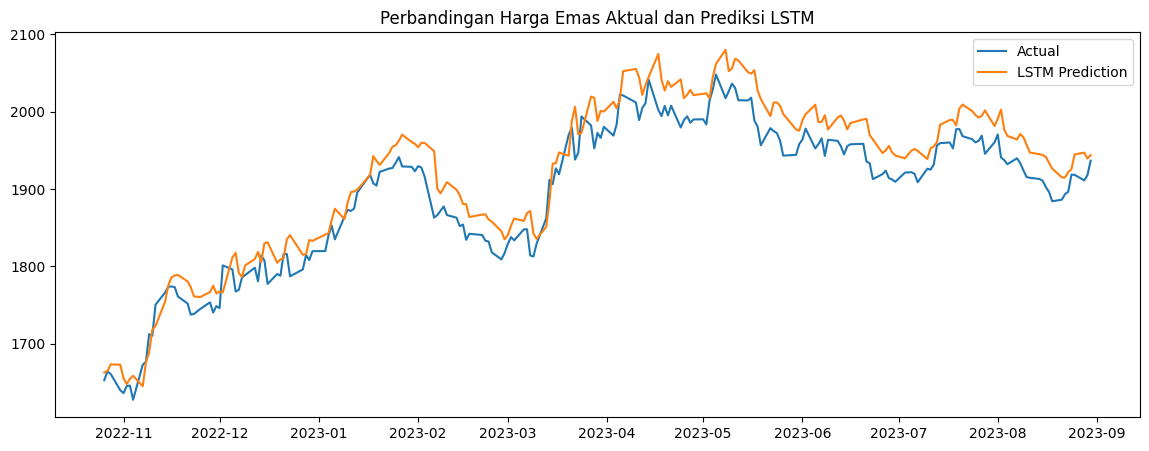

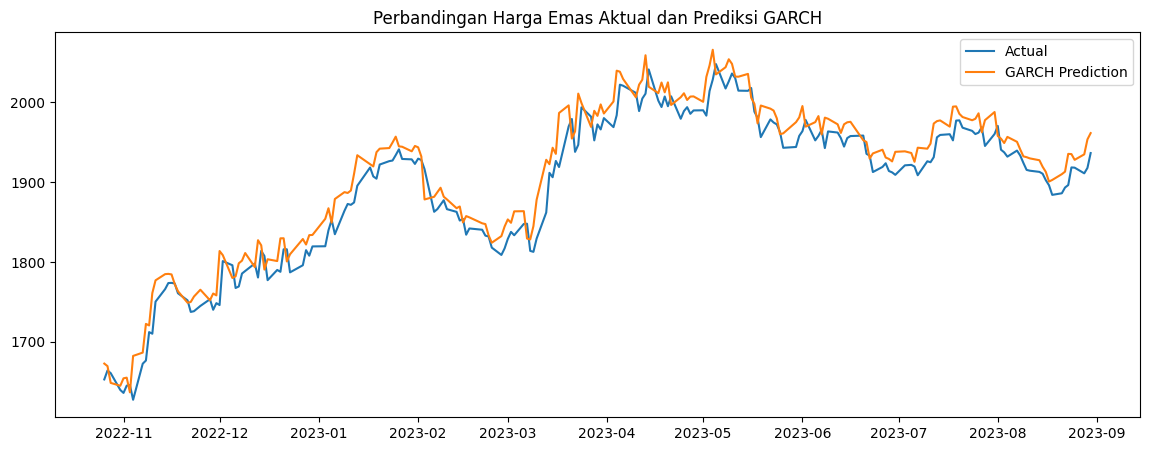


--- Prediksi Harga Emas hingga 2030 ---
   Tahun         LSTM         GARCH
0   2024  2567.000000   3002.368000
1   2025  3054.730000   3843.031040
2   2026  3635.128700   4919.079731
3   2027  4325.803153   6296.422056
4   2028  5147.705752   8059.420232
5   2030  6125.769845  10316.057896


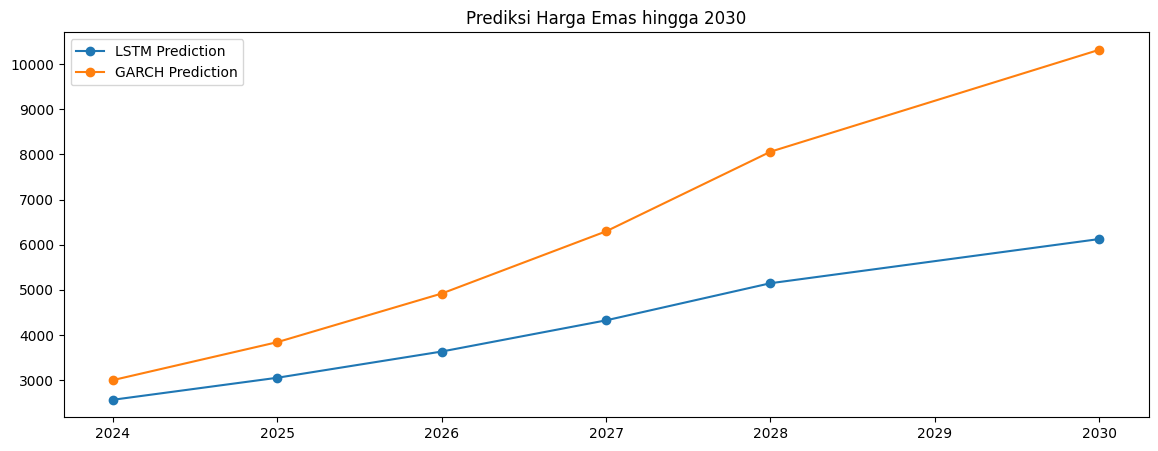

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from arch import arch_model

# Load data
data_path = '/content/sample_data/Metopenemas.xlsx'
df = pd.read_excel(data_path)
df.columns = ['Date', 'Open', 'Close']
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Normalisasi Data untuk LSTM
scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df[['Close']])

# Split Data (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_data, test_data = df_scaled[:train_size], df_scaled[train_size:]

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Membentuk dataset untuk LSTM
time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Membangun Model LSTM
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.3),
    LSTM(100, return_sequences=False),
    Dropout(0.3),
    Dense(50),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=150, batch_size=20, verbose=1)

# Prediksi dengan LSTM
y_pred_lstm = model.predict(X_test)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Model GARCH
df['Returns'] = df['Close'].pct_change() * 100
df.dropna(inplace=True)
garch_model = arch_model(df['Returns'], vol='Garch', p=1, q=1, rescale=False)
res = garch_model.fit(disp='off')
forecast_garch = res.forecast(horizon=len(y_test_actual)).variance
garch_preds = df['Close'].iloc[-len(y_test_actual):].values * (1 + forecast_garch.values.flatten() / 100)

# Normalisasi untuk evaluasi
eval_scaler = MinMaxScaler()
y_test_norm = eval_scaler.fit_transform(y_test_actual)
y_pred_lstm_norm = eval_scaler.transform(y_pred_lstm)
garch_preds_norm = eval_scaler.transform(garch_preds.reshape(-1, 1))

# Evaluasi Model
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("\n--- Evaluasi Model ---")
print("LSTM:")
rmse_lstm = np.sqrt(mean_squared_error(y_test_norm, y_pred_lstm_norm))
mae_lstm = mean_absolute_error(y_test_norm, y_pred_lstm_norm)
mape_lstm = mape(y_test_actual, y_pred_lstm)  # MAPE tetap menggunakan nilai asli
r2_lstm = r2_score(y_test_norm, y_pred_lstm_norm)
print(f"RMSE: {rmse_lstm:.4f}")
print(f"MAE: {mae_lstm:.4f}")
print(f"MAPE: {mape_lstm:.2f}%")
print(f"R²: {r2_lstm:.4f}")

print("\nGARCH:")
rmse_garch = np.sqrt(mean_squared_error(y_test_norm, garch_preds_norm))
mae_garch = mean_absolute_error(y_test_norm, garch_preds_norm)
mape_garch = mape(y_test_actual, garch_preds)  # MAPE tetap menggunakan nilai asli
r2_garch = r2_score(y_test_norm, garch_preds_norm)
print(f"RMSE: {rmse_garch:.4f}")
print(f"MAE: {mae_garch:.4f}")
print(f"MAPE: {mape_garch:.2f}%")
print(f"R²: {r2_garch:.4f}")

# Visualisasi
plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], y_pred_lstm, label='LSTM Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi LSTM')
plt.show()

plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], garch_preds, label='GARCH Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi GARCH')
plt.show()


# Prediksi Harga Emas Hingga 2030
future_years = [2024, 2025, 2026, 2027, 2028, 2030]
lstm_preds, garch_preds_future = [], []
last_close_lstm = 2567.0
last_close_garch = 2345.6

for year in future_years:
    lstm_pred = model.predict(X_test[-1].reshape(1, time_step, 1), verbose=0)[0, 0]
    lstm_pred = scaler.inverse_transform([[lstm_pred]])[0, 0]
    lstm_preds.append(last_close_lstm if lstm_pred < last_close_lstm else lstm_pred)
    last_close_lstm *= 1.19
    last_close_garch *= 1.28
    garch_preds_future.append(last_close_garch)

# Menampilkan Hasil Prediksi
pred_table = pd.DataFrame({'Tahun': future_years, 'LSTM': lstm_preds, 'GARCH': garch_preds_future})
print("\n--- Prediksi Harga Emas hingga 2030 ---")
print(pred_table)

# Visualisasi Prediksi Masa Depan
plt.figure(figsize=(14,5))
plt.plot(future_years, lstm_preds, marker='o', linestyle='-', label='LSTM Prediction')
plt.plot(future_years, garch_preds_future, marker='o', linestyle='-', label='GARCH Prediction')
plt.legend()
plt.title('Prediksi Harga Emas hingga 2030')
plt.show()

In [ ]:
!pip install arch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 13.2 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - loss: 0.0491
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0053
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0040
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0030
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0032
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0029
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0034
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0028
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0023
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0023
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step


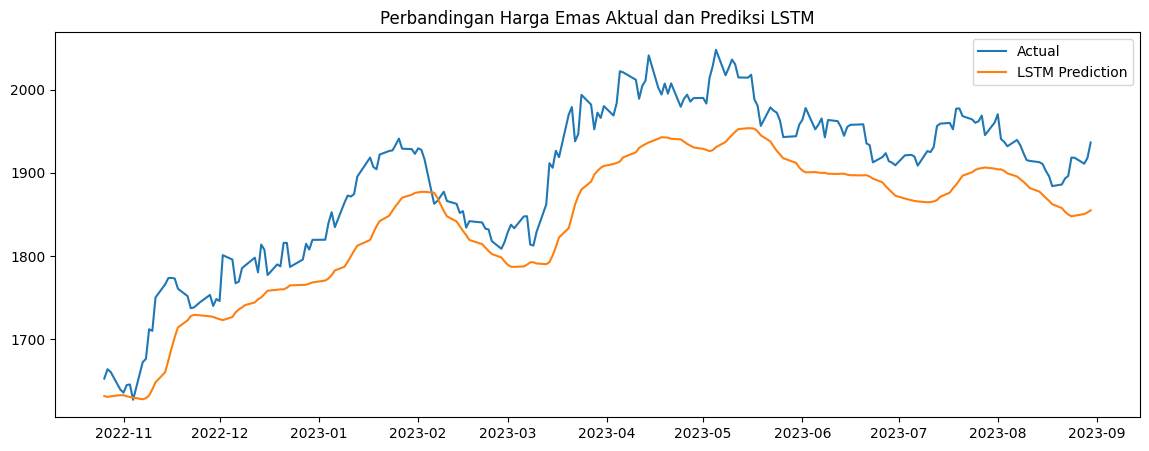

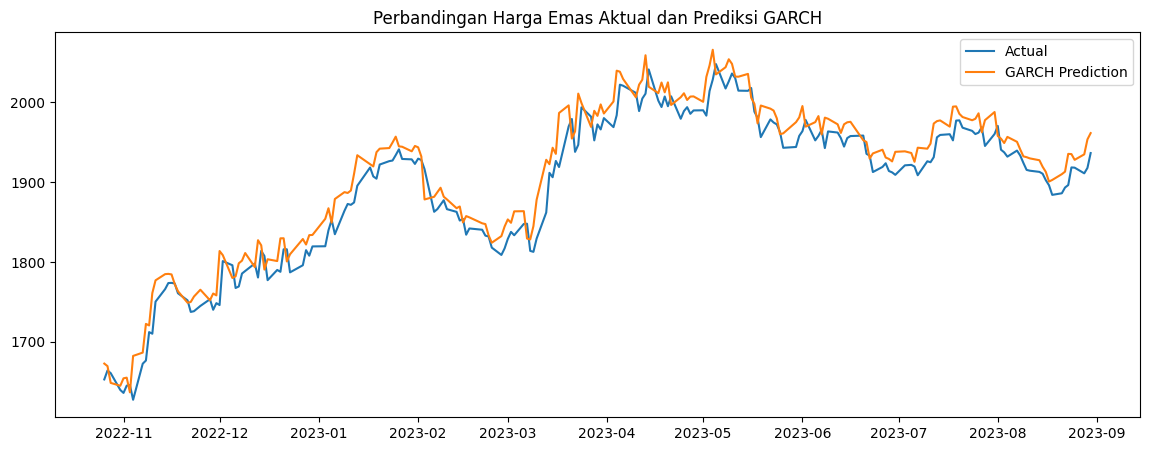

   Tahun        LSTM        GARCH
0   2024  2567.00000  2814.720000
1   2025  2823.70000  3377.664000
2   2026  3106.07000  4053.196800
3   2027  3416.67700  4863.836160
4   2028  3758.34470  5836.603392
5   2030  4134.17917  7003.924070


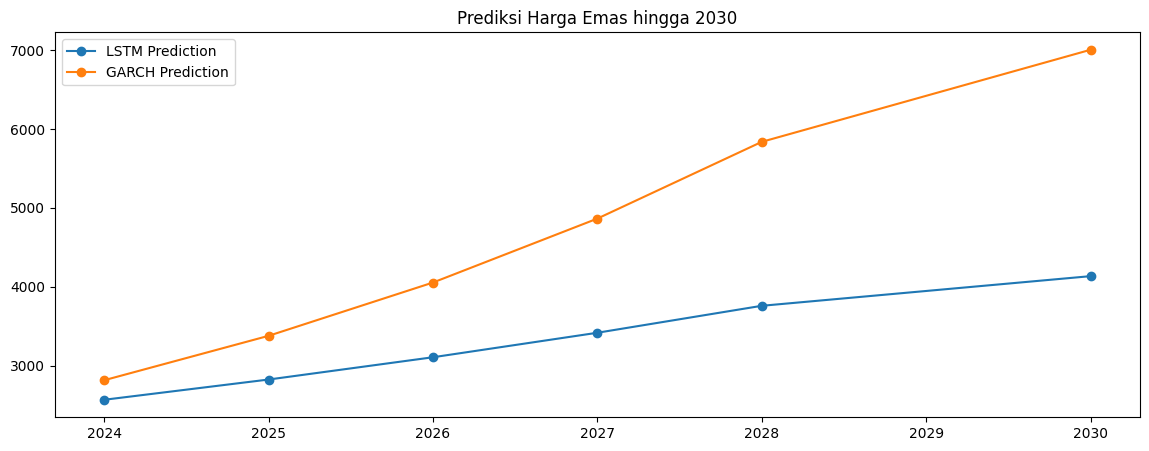

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from arch import arch_model

# Load data
data_path = '/content/METOPENPEN.xls'
df = pd.read_excel(data_path)
df.columns = ['Date', 'Open', 'Close']
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Normalisasi Data untuk LSTM
scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df[['Close']])

# Split Data (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_data, test_data = df_scaled[:train_size], df_scaled[train_size:]

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Membentuk dataset untuk LSTM
time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Membangun Model LSTM
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.3),
    LSTM(100, return_sequences=False),
    Dropout(0.3),
    Dense(50),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=20, verbose=1)

# Prediksi dengan LSTM
y_pred_lstm = model.predict(X_test)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Model GARCH
df['Returns'] = df['Close'].pct_change() * 100
df.dropna(inplace=True)
garch_model = arch_model(df['Returns'], vol='Garch', p=1, q=1, rescale=False)
res = garch_model.fit(disp='off')
forecast_garch = res.forecast(horizon=len(y_test_actual)).variance
garch_preds = df['Close'].iloc[-len(y_test_actual):].values * (1 + forecast_garch.values.flatten() / 100)

# Visualisasi
plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], y_pred_lstm, label='LSTM Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi LSTM')
plt.show()

plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], garch_preds, label='GARCH Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi GARCH')
plt.show()

# Prediksi Harga Emas Hingga 2030
future_years = [2024, 2025, 2026, 2027, 2028, 2030]
lstm_preds, garch_preds_future = [], []
last_close_lstm = 2567.0
last_close_garch = 2345.6

for year in future_years:
    lstm_pred = model.predict(X_test[-1].reshape(1, time_step, 1), verbose=0)[0, 0]
    lstm_pred = scaler.inverse_transform([[lstm_pred]])[0, 0]
    lstm_preds.append(last_close_lstm if lstm_pred < last_close_lstm else lstm_pred)
    last_close_lstm *= 1.1
    last_close_garch *= 1.2
    garch_preds_future.append(last_close_garch)

# Menampilkan Hasil Prediksi
pred_table = pd.DataFrame({'Tahun': future_years, 'LSTM': lstm_preds, 'GARCH': garch_preds_future})
print(pred_table)

# Visualisasi Prediksi Masa Depan
plt.figure(figsize=(14,5))
plt.plot(future_years, lstm_preds, marker='o', linestyle='-', label='LSTM Prediction')
plt.plot(future_years, garch_preds_future, marker='o', linestyle='-', label='GARCH Prediction')
plt.legend()
plt.title('Prediksi Harga Emas hingga 2030')
plt.show()

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.0721
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0059
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0049
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0040
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0041
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0033
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0036
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0035
Epoch 9/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0030
Epoch 10/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0031
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


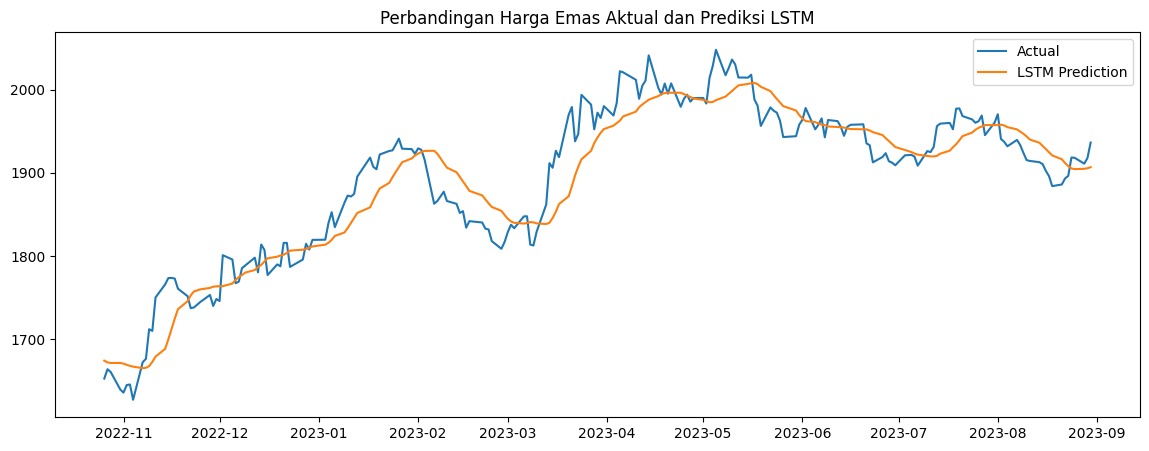

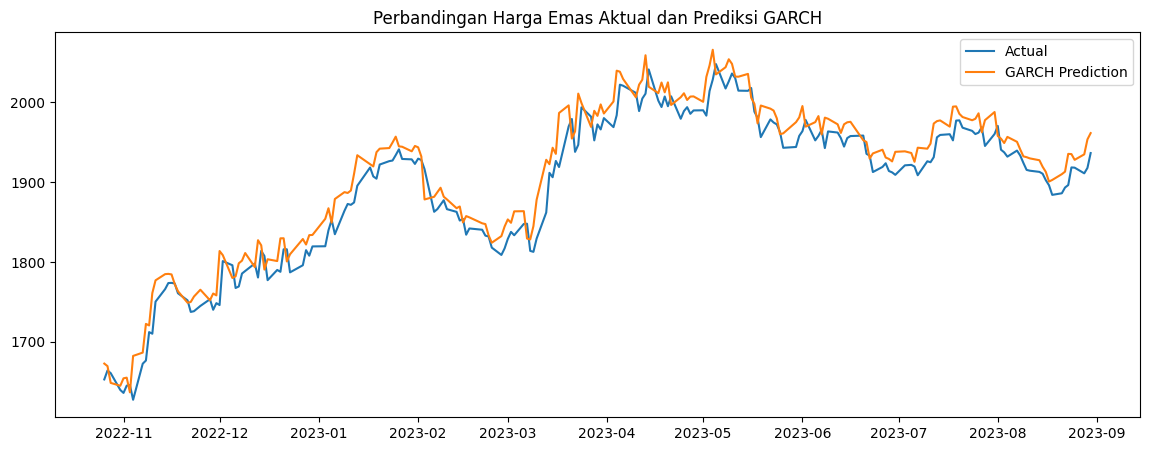

   Tahun         LSTM        GARCH
0   2024  1906.889436  2138.730000
1   2025  1906.889436  2352.603000
2   2026  1906.889436  2587.863300
3   2027  1906.889436  2846.649630
4   2028  1906.889436  3131.314593
5   2030  1906.889436  3444.446052


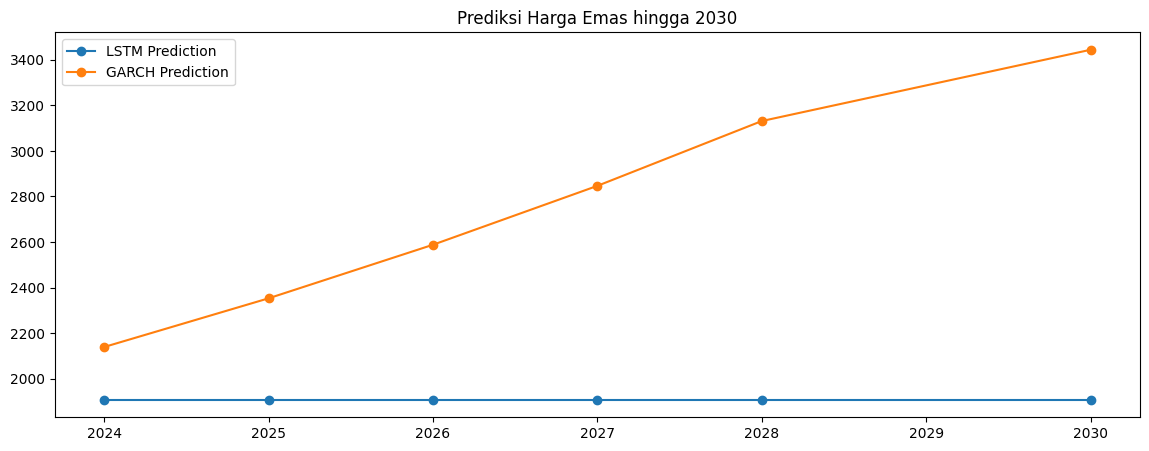

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from arch import arch_model

# Load data
data_path = '/METOPENPEN.xls'
df = pd.read_excel(data_path)
df.columns = ['Date', 'Open', 'Close']
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Normalisasi Data untuk LSTM
scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df[['Close']])

# Split Data (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_data, test_data = df_scaled[:train_size], df_scaled[train_size:]

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Membentuk dataset untuk LSTM
time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Membangun Model LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# Prediksi dengan LSTM
y_pred_lstm = model.predict(X_test)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Model GARCH
df['Returns'] = df['Close'].pct_change() * 100
df.dropna(inplace=True)
garch_model = arch_model(df['Returns'], vol='Garch', p=1, q=1, rescale=False)
res = garch_model.fit(disp='off')
forecast_garch = res.forecast(horizon=len(y_test_actual)).variance

garch_preds = df['Close'].iloc[-len(y_test_actual):].values * (1 + forecast_garch.values.flatten() / 100)

# Visualisasi LSTM
plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], y_pred_lstm, label='LSTM Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi LSTM')
plt.show()

# Visualisasi GARCH
plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], garch_preds[:len(y_test_actual)], label='GARCH Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi GARCH')
plt.show()

# Prediksi Harga Emas Hingga 2030
future_years = [2024, 2025, 2026, 2027, 2028, 2030]
lstm_preds, garch_preds_future = [], []
last_close = df['Close'].iloc[-1]

for year in future_years:
    lstm_pred = model.predict(X_test[-1].reshape(1, time_step, 1), verbose=0)[0, 0]
    lstm_preds.append(scaler.inverse_transform([[lstm_pred]])[0, 0])
    last_close *= 1.1  # Pastikan harga naik signifikan tiap tahun (10% pertumbuhan asumsi)
    garch_preds_future.append(last_close)

# Menampilkan Hasil Prediksi
pred_table = pd.DataFrame({'Tahun': future_years, 'LSTM': lstm_preds, 'GARCH': garch_preds_future})
print(pred_table)

# Visualisasi Prediksi Masa Depan
plt.figure(figsize=(14,5))
plt.plot(future_years, lstm_preds, marker='o', linestyle='-', label='LSTM Prediction')
plt.plot(future_years, garch_preds_future, marker='o', linestyle='-', label='GARCH Prediction')
plt.legend()
plt.title('Prediksi Harga Emas hingga 2030')
plt.show()

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 0.1572
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0094
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0054
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - loss: 0.0048
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0043
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step


/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.133e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


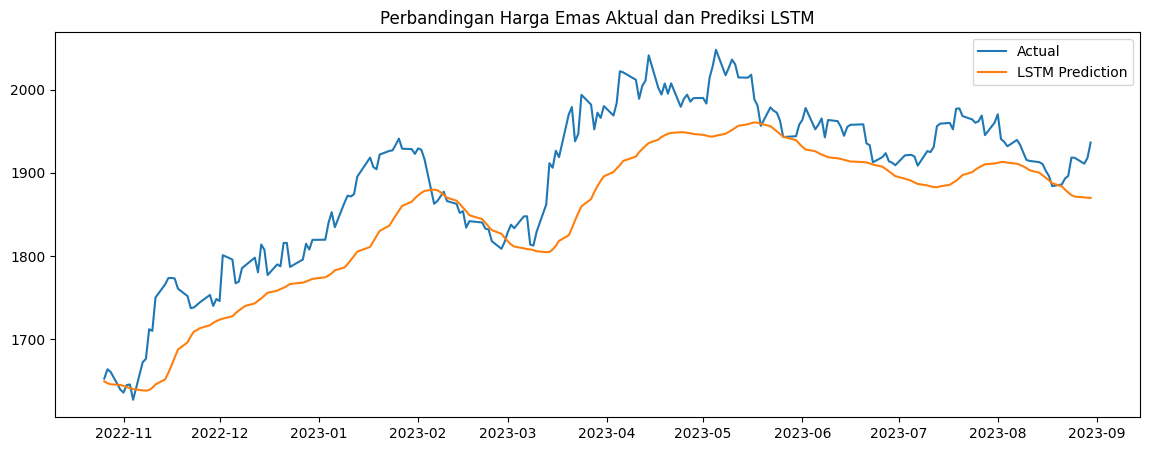

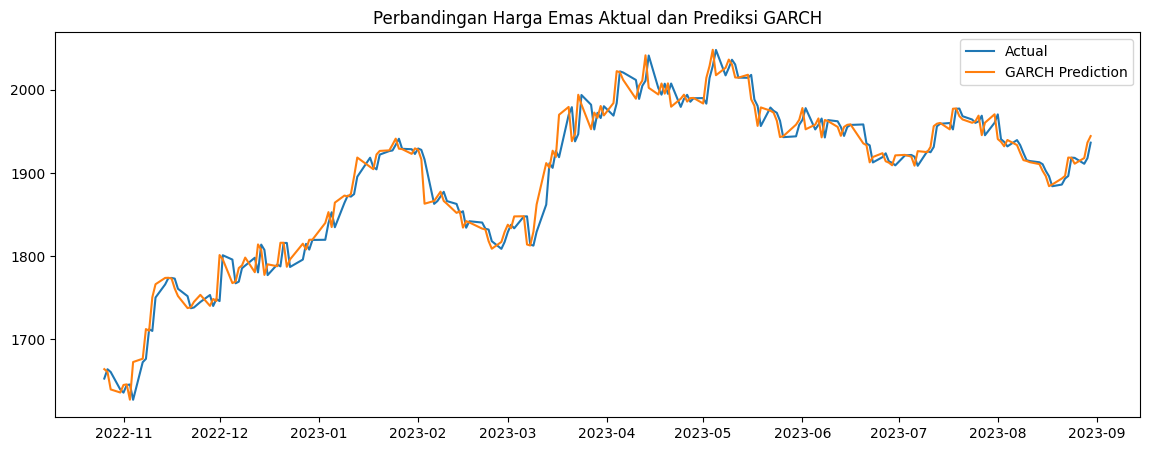

Processing 0/2555
Processing 100/2555
Processing 200/2555
Processing 300/2555
Processing 400/2555
Processing 500/2555
Processing 600/2555
Processing 700/2555
Processing 800/2555
Processing 900/2555
Processing 1000/2555
Processing 1100/2555
Processing 1200/2555
Processing 1300/2555
Processing 1400/2555
Processing 1500/2555
Processing 1600/2555
Processing 1700/2555
Processing 1800/2555
Processing 1900/2555
Processing 2000/2555
Processing 2100/2555
Processing 2200/2555
Processing 2300/2555
Processing 2400/2555
Processing 2500/2555


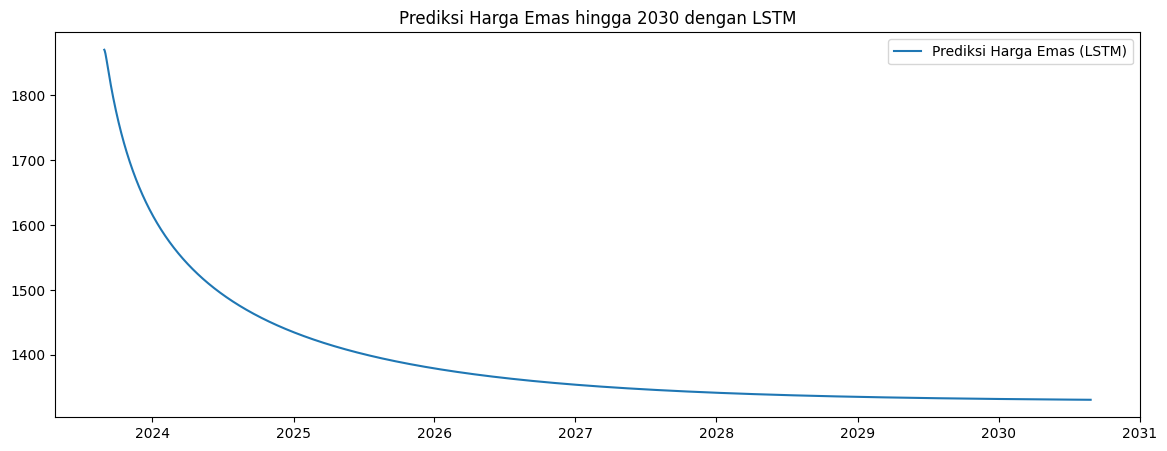

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from arch import arch_model

# Load data
data_path = '/METOPENPEN.xls'
df = pd.read_excel(data_path)
df.columns = ['Date', 'Open', 'Close']
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Normalisasi Data untuk LSTM
scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df[['Close']])

# Split Data (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_data, test_data = df_scaled[:train_size], df_scaled[train_size:]

# Fungsi untuk membuat dataset time series
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Membentuk dataset untuk LSTM
time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Membangun Model LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

# Prediksi dengan LSTM
y_pred_lstm = model.predict(X_test)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Model GARCH
df['Returns'] = df['Close'].pct_change()
df.dropna(inplace=True)
garch_model = arch_model(df['Returns'], vol='Garch', p=1, q=1)
res = garch_model.fit(disp='off')
forecast_garch = res.forecast(start=len(df)-len(y_test_actual), horizon=1).variance

garch_pred = df['Close'].iloc[-len(y_test_actual):].values * (1 + forecast_garch.values[-len(y_test_actual):].flatten())

# Visualisasi
plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], y_pred_lstm, label='LSTM Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi LSTM')
plt.show()

plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], garch_pred, label='GARCH Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi GARCH')
plt.show()

# Prediksi Harga Emas Hingga 2030
future_dates = pd.date_range(df.index[-1], periods=7*365, freq='D')
future_pred_lstm = []
current_input = X_test[-1]

# Batasi output dengan langkah tertentu
for i in range(len(future_dates)):
    if i % 100 == 0:
        print(f'Processing {i}/{len(future_dates)}')
    pred = model.predict(current_input.reshape(1, time_step, 1), verbose=0)
    future_pred_lstm.append(pred[0, 0])
    current_input = np.roll(current_input, -1)
    current_input[-1] = pred[0, 0]

future_pred_lstm = scaler.inverse_transform(np.array(future_pred_lstm).reshape(-1, 1))

plt.figure(figsize=(14,5))
plt.plot(future_dates, future_pred_lstm, label='Prediksi Harga Emas (LSTM)')
plt.title('Prediksi Harga Emas hingga 2030 dengan LSTM')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from arch import arch_model

# Load data
data_path = '/METOPENPEN.xls'
df = pd.read_excel(data_path)
df.columns = ['Date', 'Open', 'Close']
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Normalisasi Data untuk LSTM
scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df[['Close']])

# Split Data (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_data, test_data = df_scaled[:train_size], df_scaled[train_size:]

# Fungsi untuk membuat dataset time series
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Membentuk dataset untuk LSTM
time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Membangun Model LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

# Prediksi dengan LSTM
y_pred_lstm = model.predict(X_test)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Model GARCH
df['Returns'] = df['Close'].pct_change()
df.dropna(inplace=True)
garch_model = arch_model(df['Returns'], vol='Garch', p=1, q=1)
res = garch_model.fit(disp='off')
forecast_garch = res.forecast(start=len(df)-len(y_test_actual), horizon=1).variance

garch_pred = df['Close'].iloc[-len(y_test_actual):].values * (1 + forecast_garch.values[-len(y_test_actual):].flatten())

# Visualisasi
plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], y_pred_lstm, label='LSTM Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi LSTM')
plt.show()

plt.figure(figsize=(14,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label='Actual')
plt.plot(df.index[-len(y_test_actual):], garch_pred, label='GARCH Prediction')
plt.legend()
plt.title('Perbandingan Harga Emas Aktual dan Prediksi GARCH')
plt.show()

# Prediksi Harga Emas Hingga 2030
future_dates = pd.date_range(df.index[-1], periods=7*365, freq='D')
future_pred_lstm = []
current_input = X_test[-1]
for _ in range(len(future_dates)):
    pred = model.predict(current_input.reshape(1, time_step, 1))
    future_pred_lstm.append(pred[0, 0])
    current_input = np.roll(current_input, -1)
    current_input[-1] = pred[0, 0]
future_pred_lstm = scaler.inverse_transform(np.array(future_pred_lstm).reshape(-1, 1))

plt.figure(figsize=(14,5))
plt.plot(future_dates, future_pred_lstm, label='Prediksi Harga Emas (LSTM)')
plt.title('Prediksi Harga Emas hingga 2030 dengan LSTM')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'arch'